In [1]:
#Special module written for this class
#This provides access to data and to helper functions from previous weeks
#Make sure you update it before starting this notebook
import lucem_illud #pip install -U git+git://github.com/UChicago-Computational-Content-Analysis/lucem_illud.git


#All these packages need to be installed from pip
#These are all for the cluster detection
import sklearn
import sklearn.feature_extraction.text
import sklearn.pipeline
import sklearn.preprocessing
import sklearn.datasets
import sklearn.cluster
import sklearn.decomposition
import sklearn.metrics

import scipy #For hierarchical clustering and some visuals
#import scipy.cluster.hierarchy
import gensim#For topic modeling
import requests #For downloading our datasets
import numpy as np #for arrays
import pandas #gives us DataFrames
import matplotlib.pyplot as plt #For graphics
import matplotlib.cm #Still for graphics
import seaborn as sns #Makes the graphics look nicer

#This 'magic' command makes the plots work better
#in the notebook, don't use it outside of a notebook.
#Also you can ignore the warning, it
%matplotlib inline

import itertools
import json

In [2]:
import pandas as pd
import numpy as np
import os
import zipfile as zip
import csv

# Import Time-series data

In [3]:
file_path_old = "C:/Users/Louisa Zhao/Desktop/21 Spring Quarter/Perspective/Data/patentsview/cloud patent data/completed/cloud patent 2010-2014.csv"
file_path_new1 = "C:/Users/Louisa Zhao/Desktop/21 Spring Quarter/Perspective/Data/patentsview/cloud patent data/completed/cloud patent 2015-2017(completed).csv"
file_path_new2 = "C:/Users/Louisa Zhao/Desktop/21 Spring Quarter/Perspective/Data/patentsview/cloud patent data/completed/cloud patent 2018-2020.csv"

In [4]:
old_pd = pd.read_csv(file_path_old,index_col=0)
new_pd1 = pd.read_csv(file_path_new1,index_col=0)
new_pd2 = pd.read_csv(file_path_new2,index_col=0)

In [5]:
new_pd1[:10]

,patent_num_combined_citations,patent_number,patent_title,patent_abstract,assignee_organization,cited_lst,citedby_lst,inventor_name_lst,inventor_num
0,3,8930022,Systems and methods for determining a status o...,Methods and systems for determining a status o...,GOOGLE LLC,['7600593'],"['10011013', '10134014', '10430744', '10552803...","['Kuffner, Jr.', 'Hickman']",2
1,107,8930536,Virtual private cluster,"The present invention provides a system, metho...","Adaptive Computing Enterprises, Inc.","['4412288', '4525780', '5257374', '5761484', '...",[None],['Jackson'],1
2,76,8930542,Dynamically building a set of compute nodes to...,"A method, system and computer program product ...",International Business Machines Corporation,"['8140817', '8478845', '8489812', '8612785', '...","['10554508', '10585712', '10791174', '9455881']","['Hockett', 'Hogstrom', 'Sheard', 'Ashok', 'Br...",6
3,76,8930543,Dynamically building a set of compute nodes to...,"A method, system and computer program product ...",International Business Machines Corporation,"['8140817', '8478845', '8489812', '8612785', '...","['10048889', '10108652', '10152251', '10162528...","['Hockett', 'Hogstrom', 'Sheard', 'Ashok', 'Br...",6
4,34,8930896,Data anonymity and separation for user computa...,This disclosure includes techniques for using ...,"Amazon Technologies, Inc.","['4805107', '5822608', '6185567', '6988139', '...","['10416966', '10417450', '10419493', '10423996...",['Wiggins'],1
5,28,8931038,System and method for a cloud computing abstra...,"According to one system of the invention, the ...","ServiceMesh, Inc.","['6847970', '6880002', '7698230']","['10044757', '10063595', '10075537', '10097584...","['Hill', 'Pulier', 'Martinez']",3
6,6,8931051,Scalable and highly available clustering for l...,Scaling and highly available clustering for la...,"Microsoft Technology Licensing, LLC","['6427163', '7239606']",['10049011'],"['Sekaran', 'Ananthanarayanan', 'Kumar', 'Nara...",5
7,17,8935317,Dynamic partitioning of applications between c...,Optimization mechanism that dynamically splits...,"Microsoft Technology Licensing, LLC","['5457797', '5805804', '6983463', '7437707']","['10310872', '10368283', '10624013', '9313299']",['Jain'],1
8,14,8935318,Opportunistic job processing in a distributed ...,A central storage configured to store one or m...,GOOGLE LLC,"['5963965', '8392482']","['10044572', '10250498', '10348488', '10536373...","['Belov', 'Konerding', 'Breckenridge']",3
9,33,8935372,"Mediation server, terminals and distributed pr...",A highly convenient data processing technique ...,SONY COMPUTER ENTERTAINMENT INC.,"['6718361', '6748447', '7346682', '7401129', '...",[None],"['Maegawa', 'Morisada', 'Kageyama', 'Yamane', ...",6


In [6]:
new_pd1.groupby('assignee_organization').mean()[:20]

,patent_num_combined_citations,patent_number,inventor_num
assignee_organization,,,
"A9.com, Inc.",3.500000,9.429560e+06,1.000000
ABL IP Holding LLC,37.500000,9.338248e+06,3.000000
"ADVANCED MICRO DEVICES, INC.",20.000000,9.152532e+06,4.000000
AMDOCS DEVELOPMENT LIMITED,18.000000,9.843532e+06,1.000000
AMDOCS SOFTWARE SYSTEMS LIMITED,3.000000,9.306867e+06,1.000000
AO KASPERSKY LAB,79.000000,9.582335e+06,3.000000
ARRIS ENTERPRISES LLC,8.000000,9.189287e+06,1.000000
"AT&T INTELLECTUAL I, LP",3.000000,8.949842e+06,2.000000
"AT&T Intellectual Property I, L.P.",44.400000,9.356219e+06,4.600000


In [7]:
#Apply our functions
#old_pd['text'] = old_pd['patent_title'] + old_pd['patent_abstract']
old_pd['tokenized_text'] = old_pd['text'].apply(lambda x: lucem_illud.word_tokenize(x))
old_pd['normalized_tokens'] = old_pd['tokenized_text'].apply(lambda x: lucem_illud.normalizeTokens(x))

new_pd1['text'] = new_pd1['patent_title'] + new_pd1['patent_abstract']
new_pd1['tokenized_text'] = new_pd1['text'].apply(lambda x: lucem_illud.word_tokenize(x))
new_pd1['normalized_tokens'] = new_pd1['tokenized_text'].apply(lambda x: lucem_illud.normalizeTokens(x))

new_pd2['text'] = new_pd2['patent_title'] + new_pd2['patent_abstract']
new_pd2['tokenized_text'] = new_pd2['text'].apply(lambda x: lucem_illud.word_tokenize(x))
new_pd2['normalized_tokens'] = new_pd2['tokenized_text'].apply(lambda x: lucem_illud.normalizeTokens(x))

In [8]:
old = len(old_pd)
new1 = len(new_pd1)
new2 = len(new_pd2)

time_slice = [old,new1,new2]

In [9]:
corpus = []
for i in old_pd['normalized_tokens']:
    corpus.append(i)
for i in new_pd1['normalized_tokens']:
    corpus.append(i)
for i in new_pd2['normalized_tokens']:
    corpus.append(i)

In [11]:
corpus2 = []
for i in old_pd['normalized_tokens']:
    corpus2 += i
#corpus2

In [16]:
from gensim.models import ldaseqmodel
from gensim.corpora import Dictionary, bleicorpus
import numpy
from gensim.matutils import hellinger

In [17]:
dictionary =gensim.corpora.Dictionary(corpus)

In [18]:
t_corpus = [dictionary.doc2bow(text) for text in corpus]

In [19]:
ldaseq = ldaseqmodel.LdaSeqModel(corpus=t_corpus, id2word=dictionary, time_slice=time_slice, num_topics=4)

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\gensim\models\ldaseqmodel.py:293: RuntimeWarning: divide by zero encountered in double_scalars
  convergence = np.fabs((bound - old_bound) / old_bound)


In [20]:
ldaseq.print_topics(time=0)

[[('virtual', 0.04808866466283326),
  ('machine', 0.03255991637950347),
  ('network', 0.0287664495441357),
  ('compute', 0.026148095095215717),
  ('cloud', 0.023465845351462764),
  ('system', 0.02089471772778605),
  ('server', 0.018422245764928773),
  ('node', 0.01661107033656529),
  ('include', 0.014821762977774669),
  ('method', 0.01259321934835073),
  ('process', 0.012092993105698807),
  ('computer', 0.010928450524611447),
  ('device', 0.009246981221557267),
  ('communication', 0.007861171583081902),
  ('provide', 0.007736613175829509),
  ('datum', 0.0073091704155020115),
  ('private', 0.00679005121767486),
  ('physical', 0.006713693516506745),
  ('receive', 0.006521427786939196),
  ('resource', 0.0063579884735397284)],
 [('cloud', 0.07225718780514936),
  ('service', 0.05300760221590407),
  ('application', 0.03537936308853288),
  ('system', 0.022597869163645964),
  ('compute', 0.016063377464620204),
  ('provide', 0.014733403561657355),
  ('base', 0.012705797359782764),
  ('environme

In [22]:
ldaseq.print_topic_times(topic=1)

[[('cloud', 0.07225718780514936),
  ('service', 0.05300760221590407),
  ('application', 0.03537936308853288),
  ('system', 0.022597869163645964),
  ('compute', 0.016063377464620204),
  ('provide', 0.014733403561657355),
  ('base', 0.012705797359782764),
  ('environment', 0.012542178551568361),
  ('platform', 0.011444889436682005),
  ('include', 0.01129816810818547),
  ('method', 0.011086403864799059),
  ('user', 0.010804777712447186),
  ('component', 0.010396208412359),
  ('tenant', 0.010082191722927571),
  ('infrastructure', 0.00964231753561644),
  ('provider', 0.008665816152314246),
  ('management', 0.00826434774754727),
  ('information', 0.00749929371242246),
  ('software', 0.007365704248749111),
  ('provision', 0.0064665532248275445)],
 [('cloud', 0.07378420915647473),
  ('service', 0.049633156686919935),
  ('application', 0.03297499417734601),
  ('system', 0.022954989529015157),
  ('compute', 0.016372338474546992),
  ('provide', 0.015079769184333252),
  ('base', 0.0124282716841993

In [80]:
train_texts

[['john', 'likes', 'to', 'watch', 'movies', 'mary', 'likes', 'movies', 'too'],
 ['john', 'also', 'likes', 'to', 'watch', 'football', 'games']]

In [78]:
train_corpus = [dictionary.doc2bow(text) for text in train_texts]

[[(0, 1), (1, 2), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1)],
 [(0, 1), (1, 1), (4, 1), (6, 1), (7, 1), (8, 1), (9, 1)]]

In [61]:
train = ["John likes to watch movies Mary likes movies too" ,
         "John also likes to watch football games" ]

test = ["Football is my dream"]

train_texts = [[word for word in document.lower().split()] for document in train]
test_texts = [[word for word in document.lower().split()] for document in test]

dictionary =gensim.corpora.Dictionary(train_texts)

train_corpus = [dictionary.doc2bow(text) for text in train_texts]
test_corpus = [dictionary.doc2bow(text) for text in test_texts]

ldaModel = gensim.models.LdaModel(corpus=train_corpus , 
             id2word=dictionary , num_topics=2,time)
bound_perplex = ldaModel.bound(test_corpus)

In [73]:
train_texts

[['john', 'likes', 'to', 'watch', 'movies', 'mary', 'likes', 'movies', 'too'],
 ['john', 'also', 'likes', 'to', 'watch', 'football', 'games']]

In [65]:
train_corpus

[[(0, 1), (1, 2), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1)],
 [(0, 1), (1, 1), (4, 1), (6, 1), (7, 1), (8, 1), (9, 1)]]

# Topic proportion

It seems the 4 topic are quite stable. Compare the distribution of topic

# LDA Topic modelling

In [113]:
old_corpus = []
for i in old_pd['normalized_tokens']:
    old_corpus.append(i)

In [117]:
dictionary =gensim.corpora.Dictionary(old_corpus)
train_corpus1 = [dictionary.doc2bow(text) for text in old_corpus]

In [122]:
ldaModel = gensim.models.LdaModel(corpus=train_corpus1 , 
             id2word=dictionary , num_topics=4)

In [123]:
ldaModel.print_topics()

[(0,
  '0.029*"service" + 0.028*"cloud" + 0.021*"system" + 0.020*"compute" + 0.018*"resource" + 0.017*"application" + 0.016*"network" + 0.016*"include" + 0.013*"device" + 0.012*"environment"'),
 (1,
  '0.041*"cloud" + 0.038*"service" + 0.015*"application" + 0.014*"datum" + 0.014*"compute" + 0.013*"user" + 0.012*"system" + 0.011*"base" + 0.011*"environment" + 0.011*"resource"'),
 (2,
  '0.034*"resource" + 0.023*"cloud" + 0.023*"datum" + 0.017*"compute" + 0.017*"application" + 0.015*"include" + 0.014*"base" + 0.013*"system" + 0.013*"service" + 0.011*"associate"'),
 (3,
  '0.048*"datum" + 0.020*"process" + 0.018*"resource" + 0.016*"node" + 0.014*"method" + 0.013*"cloud" + 0.012*"compute" + 0.012*"include" + 0.012*"application" + 0.012*"request"')]

In [136]:
def topic_modelling(pd):
    corpus = []
    for i in pd['normalized_tokens']:
        corpus.append(i)
    dictionary =gensim.corpora.Dictionary(corpus)
    train_corpus1 = [dictionary.doc2bow(text) for text in corpus]
    ldaModel = gensim.models.LdaModel(corpus=train_corpus1 , 
             id2word=dictionary , num_topics=4)
    return ldaModel

In [137]:
lda = topic_modelling(new_pd2)
lda.print_topics()

[(0,
  '0.038*"datum" + 0.026*"service" + 0.022*"resource" + 0.022*"cloud" + 0.015*"base" + 0.014*"system" + 0.013*"include" + 0.012*"method" + 0.012*"compute" + 0.011*"virtual"'),
 (1,
  '0.033*"cloud" + 0.028*"datum" + 0.018*"application" + 0.014*"system" + 0.013*"compute" + 0.012*"base" + 0.012*"process" + 0.011*"method" + 0.011*"include" + 0.011*"resource"'),
 (2,
  '0.028*"resource" + 0.025*"datum" + 0.022*"compute" + 0.018*"network" + 0.016*"include" + 0.014*"device" + 0.014*"application" + 0.013*"process" + 0.013*"node" + 0.013*"cloud"'),
 (3,
  '0.037*"service" + 0.034*"cloud" + 0.022*"application" + 0.021*"resource" + 0.021*"system" + 0.014*"compute" + 0.013*"device" + 0.011*"include" + 0.011*"environment" + 0.011*"method"')]

calculate  the topic for each patents

In [150]:
#old_corpus 
old_corpus_whole = []
for text in old_pd['normalized_tokens']:
    for t in text:
        old_corpus_whole.append(t)
old_corpus_whole[:10]

['distribute',
 'datum',
 'set',
 'indexingan',
 'apparatus',
 'include',
 'processor',
 'receive',
 'search',
 'criterium']

In [152]:
doc_football_2 = dictionary.doc2bow(old_corpus_whole)
doc_football_2 = ldaModel[doc_football_2]

In [153]:
print(doc_football_2)

[(0, 0.30269176), (1, 0.07158365), (2, 0.3360382), (3, 0.28968638)]


In [147]:
#compare each patent
new_corpus1 = []
for i in new_pd1['normalized_tokens']:
    new_corpus1.append(i)
new_corpus1[0]

['system',
 'method',
 'determine',
 'status',
 'component',
 'robotic',
 'devicemethods',
 'system',
 'determine',
 'status',
 'component',
 'robotic',
 'device',
 'provide',
 'example',
 'method',
 'include',
 'trigger',
 'action',
 'component',
 'robotic',
 'device',
 'responsively',
 'receive',
 'information',
 'associate',
 'action',
 'component',
 'sensor',
 'method',
 'include',
 'compute',
 'system',
 'have',
 'processor',
 'memory',
 'compare',
 'information',
 'calibration',
 'datum',
 'determine',
 'status',
 'component',
 'base',
 'comparison',
 'example',
 'calibration',
 'datum',
 'include',
 'information',
 'derive',
 'datum',
 'receive',
 'pool',
 'robotic',
 'device',
 'utilize',
 'similar',
 'component',
 'component',
 'determine',
 'status',
 'include',
 'information',
 'associate',
 'performance',
 'component',
 'respect',
 'performance',
 'similar',
 'component',
 'pool',
 'robotic',
 'device',
 'example',
 'robotic',
 'device',
 'self',
 'calibrate',
 'component',

In [155]:
doc_football_new = dictionary.doc2bow(new_corpus1[0])

In [156]:
doc_football_new = ldaModel[doc_football_new]
hellinger(doc_football_new, doc_football_2)

0.45024868384662653

In [181]:
count = 0
sim_dict = {}
sim_lst = []
for i in new_corpus1:
    count += 1
    doc_football_new = dictionary.doc2bow(i)
    doc_football_new = ldaModel[doc_football_new]
    sim = hellinger(doc_football_new, doc_football_2)
    sim_dict[count-1] = sim
    sim_lst.append(sim)

In [182]:
sim_dict

{0: 0.4502488288224523,
 1: 0.6458166749073643,
 2: 0.2461544940279649,
 3: 0.24653536304587856,
 4: 0.2841899987009492,
 5: 0.6345419322015802,
 6: 0.20391574534748108,
 7: 0.34782144459096775,
 8: 0.2059566534393079,
 9: 0.32863935230979385,
 10: 0.4022560737044494,
 11: 0.6454076981309099,
 12: 0.5514386226824771,
 13: 0.4802511189808321,
 14: 0.5139297865153579,
 15: 0.45318976716270676,
 16: 0.1930549152316361,
 17: 0.20503297370732282,
 18: 0.30504570939588027,
 19: 0.2959762474955619,
 20: 0.4432119526204976,
 21: 0.16501402760043568,
 22: 0.4065000305376447,
 23: 0.43768029614883686,
 24: 0.3507214590565194,
 25: 0.44876902063499235,
 26: 0.44681491883953517,
 27: 0.6278835219253474,
 28: 0.51147131682718,
 29: 0.28622293169856783,
 30: 0.7276001314223154,
 31: 0.5157512555607505,
 32: 0.6094720526302309,
 33: 0.48899151671768687,
 34: 0.19769271152082687,
 35: 0.4624473169871692,
 36: 0.6466298595754365,
 37: 0.5011614778997593,
 38: 0.25742510107973476,
 39: 0.410241121672071

In [183]:
citation_lst = [i for i in new_pd1['patent_num_combined_citations']]

In [191]:
X = np.array(citation_lst).reshape((-1, 1))
Y = np.array(sim_lst).reshape((-1, 1))

In [192]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(Y,X)

In [194]:
reg.score(X, Y)

-263004750.411996

In [195]:
reg.coef_

array([[26.18018844]])

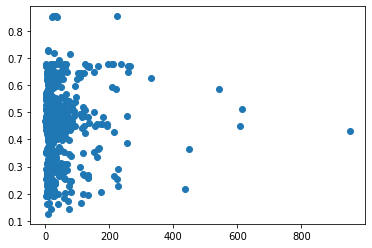

In [202]:
plt.scatter(citation_lst,sim_lst)

In [203]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

In [204]:
# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

In [212]:
s = [i*10 for i in sim_lst]

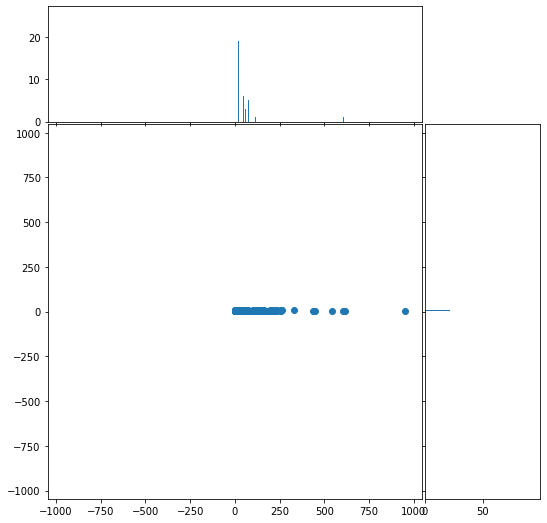

In [213]:
# start with a square Figure
fig = plt.figure(figsize=(8, 8))

ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

# use the previously defined function
scatter_hist(citation_lst,s, ax, ax_histx, ax_histy)

In [201]:
from pandas import DataFrame

stat = DataFrame(citation_lst,sim_lst)
stat.to_csv("citation_sim.csv")

In [215]:
sum(time_slice)

1164